In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import optuna
import tensorflow as tf
from statsmodels.graphics.tsaplots import plot_ccf
from statsmodels.tsa.stattools import grangercausalitytests


import warnings

## NOTE:
- Our data is quarterly, thus neural networks do not preform decently with such lack of data (~140 data points). 
- Aligning with our end goal of practice + showcasing our work, we will interpolate more data
- In real world cases, where a credit card company has its own data, interpolation (most likely!) wont be necessary



features that we will use:
- 'charge_off',      # target's own history
- 'delinquency',     # strongest credit predictor
- 'sp500_return',    # macro leading indicator
- 'anomaly_flag'     # structural breaks


While this wont fix the amount of data problem, we will attempt to use a shallow model to bypass that. 


Load up data

In [ ]:
def fix_df(df):

    a=df.groupby(df['date'])['value'].mean().round(2)
    
    b = pd.to_datetime(df['date'].unique())

    df = pd.DataFrame({
        'date':b,
        'value':a.values
    })

    df = df.set_index('date')

    return df

In [ ]:
import yfinance as yf

#S&P
sp500 = yf.download('^GSPC', start ='1985-01-01', end='2025-10-01')
sp500_monthly = sp500['Close'].resample('MS').last()
sp500_monthly = sp500_monthly.pct_change()
sp500_monthly.name = 'sp500_return'


# Charge off
charge_off = pd.read_csv('../data/CORCCACBS.csv')

charge_off = fix_df(charge_off)

#Delinquency
delinquency = pd.read_csv('../data/DRCCLACBS.csv')
delinquency = fix_df(delinquency)
delinquency_lag = delinquency.shift(1) #we shift by one since this would be data leakage. Leaking future information

#Anamoly flag
def featureng(df):
    df_fe = df.copy()
    anamoly_flag = ((df_fe['charge_off'] > 5) | 
                          (df_fe['charge_off'] < 2.0)).astype(int)
    return anamoly_flag

charge_off_anamolyflag = featureng(charge_off)



#Have to fix up anamoly flag + delinquency + merge them, THen check correlation, etc.

[*********************100%***********************]  1 of 1 completed


ValueError: array length 140 does not match index length 139

: 

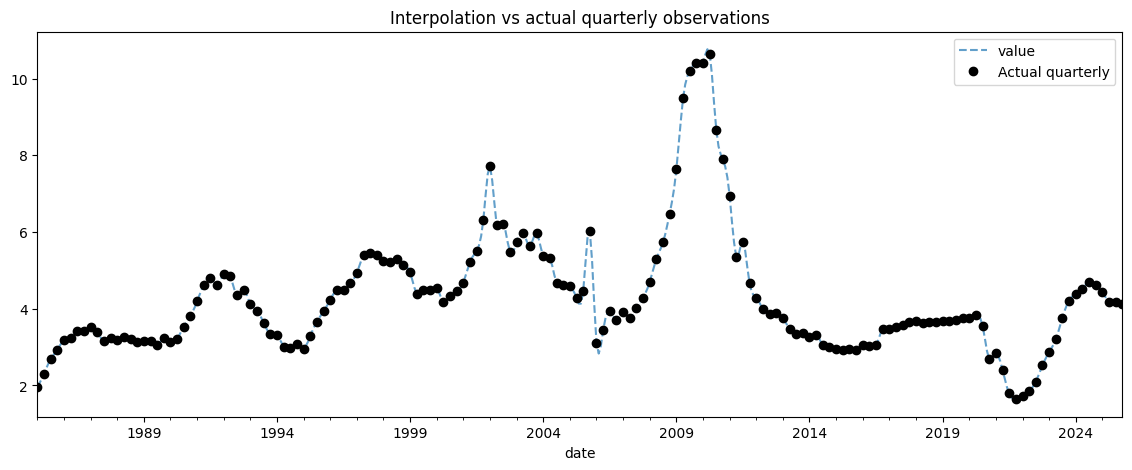

In [7]:
charge_off_monthly = charge_off.resample('MS').mean()

#Cubic spline interpolation
co_monthly_spline = charge_off_monthly.interpolate(method='cubicspline')


fig, ax = plt.subplots(figsize=(14, 5))
co_monthly_spline.plot(ax=ax, label='Cubic spline', linestyle='--', alpha=0.7)
charge_off['value'].plot(ax=ax, label='Actual quarterly', marker='o', 
                 linewidth=0, markersize=6, color='black')
ax.legend()
plt.title('Interpolation vs actual quarterly observations')
plt.show()

(0, 5)
Empty DataFrame
Columns: [value, ^GSPC, date, value, charge_off]
Index: []


KeyError: 'sp500_return'

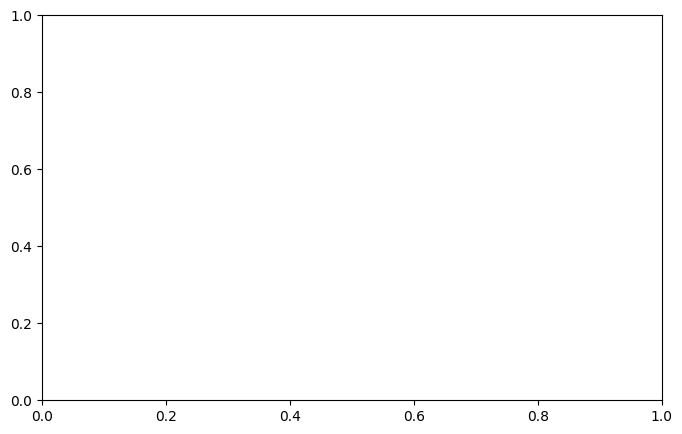

: 

In [ ]:
"""df_combined = pd.DataFrame({
    's&p500_returns': sp500_monthly,
    'delinquency_lag': delinquency_lag,
    'anamoly_flag': charge_off_anamolyflag,
    'charge-off': charge_off
}).dropna()"""
df_combined = pd.concat([co_monthly_spline, sp500_monthly, delinquency_lag, charge_off_anamolyflag], axis=1).dropna()
print(df_combined.shape)
print(df_combined.head())


# Scatter plot
fig, ax = plt.subplots(figsize=(8,5))
ax.scatter(df_combined['sp500_return'], 
           df_combined['charge_off'], alpha=0.5)
ax.set_xlabel('S&P 500 monthly return')
ax.set_ylabel('Charge-off rate')
plt.show()

# Correlation
print(df_combined.corr())

# 3. CCF, checking if S&P lead charge-off
plot_ccf(df_combined['charge_off'], 
         df_combined['sp500_return'], 
         lags=12)
plt.title('CCF: does S&P lead charge-off?')
plt.show()


#
grangercausalitytests(
    df_combined[['value', 'sp500_return']].dropna(), 
    maxlag=6
)

In [ ]:
def traintestsplit(df):
    train = df.loc[:'2015']
    val = df.loc['2016':'2019']
    test = df.loc['2020':]

    return train,val ,test

train_set, val_set, test_set = traintestsplit(df_monthly_spline)


490


Creating our timeseries data set via Tensorflow

GradDescent requires IID, shuffling training windows (not the contents)
- so the model's weight doesn't update / get biased toward whatever pattern is most recent!

In [4]:
seq_length = 8

train_dataset = tf.keras.utils.timeseries_dataset_from_array(
    train_set,targets = train_set[seq_length:],#targets are 3 steps into the future
    sequence_length=seq_length, batch_size=4,shuffle = True, seed=11
    )

val_dataset = tf.keras.utils.timeseries_dataset_from_array(
    val_set, targets=val_set[seq_length:], sequence_length=seq_length, batch_size=4, shuffle= True, seed=11
)

test_dataset = tf.keras.utils.timeseries_dataset_from_array(
    test_set, targets=test_set[seq_length:], sequence_length=seq_length, batch_size=4,shuffle= True, seed=11
)

Trying a basic linear model first: Using Huber Loss

In [5]:
tf.random.set_seed(11)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(1,input_shape=[seq_length])
])

early_stopping_cb = tf.keras.callbacks.EarlyStopping(monitor='val_mae',
                                                     patience=50,
                                                     restore_best_weights=True)

opt = tf.keras.optimizers.SGD(learning_rate=.02,momentum=0.9)


model.compile(loss=tf.keras.losses.Huber(),optimizer=opt,metrics=['mae'])


history = model.fit(train_dataset, validation_data=val_dataset, epochs=500,
                    callbacks=[early_stopping_cb])

Epoch 1/500


c:\Users\Marwa\anaconda3\envs\cc_abs\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 7.5233 - mae: 8.0186 - val_loss: 3.2450 - val_mae: 3.7450
Epoch 2/500
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.7791 - mae: 3.2653 - val_loss: 5.2141 - val_mae: 5.7141
Epoch 3/500
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.8519 - mae: 4.3343 - val_loss: 3.9096 - val_mae: 4.4096
Epoch 4/500
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.8933 - mae: 3.3770 - val_loss: 0.7939 - val_mae: 1.2939
Epoch 5/500
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.1856 - mae: 3.6582 - val_loss: 2.5860 - val_mae: 3.0860
Epoch 6/500
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.0187 - mae: 4.4948 - val_loss: 0.4246 - val_mae: 0.9192
Epoch 7/500
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9195 - mae: 1.3578 - val_loss: 0.0065 - val_mae: 0.0740
Epoch 8/500
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.0492 - mae: 2.5023 - val_loss: 0.0661 - val_mae: 0.3174
Epoch 9/500
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.8666 - mae: 2.

Best epoch: 7, Val MAE: 0.0740


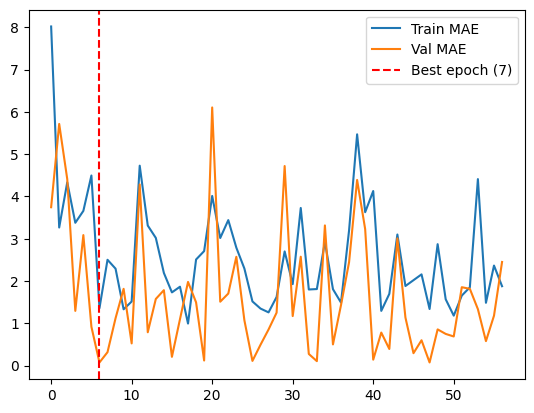

In [6]:
best_val_mae = min(history.history['val_mae'])
best_epoch = history.history['val_mae'].index(best_val_mae) + 1  # +1 since epochs start at 1
print(f"Best epoch: {best_epoch}, Val MAE: {best_val_mae:.4f}")

plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.axvline(x=best_epoch-1, color='red', linestyle='--', label=f'Best epoch ({best_epoch})')
plt.legend()
plt.show()

Using a simple RNN

In [9]:
model = tf.keras.Sequential([
    tf.keras.layers.SimpleRNN(32,input_shape=[None,1]), #Univariate sequence of any length 
    tf.keras.layers.Dense(1) #no activation function by default
])

early_stopping_cb = tf.keras.callbacks.EarlyStopping(monitor='val_mae',
                                                     patience=50,
                                                     restore_best_weights=True)

opt = tf.keras.optimizers.SGD(learning_rate=.02,momentum=0.9)


model.compile(loss=tf.keras.losses.Huber(),optimizer=opt,metrics=['mae'])


history = model.fit(train_dataset, validation_data=val_dataset, epochs=500,
                    callbacks=[early_stopping_cb])

Epoch 1/500


c:\Users\Marwa\anaconda3\envs\cc_abs\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.8592 - mae: 1.2846 - val_loss: 0.1944 - val_mae: 0.6227
Epoch 2/500
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3514 - mae: 0.7099 - val_loss: 0.0746 - val_mae: 0.3847
Epoch 3/500
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2722 - mae: 0.5875 - val_loss: 8.7799e-04 - val_mae: 0.0325
Epoch 4/500
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3222 - mae: 0.6587 - val_loss: 0.0332 - val_mae: 0.2543
Epoch 5/500
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3729 - mae: 0.7186 - val_loss: 0.0497 - val_mae: 0.3135
Epoch 6/500
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2590 - mae: 0.5781 - val_loss: 0.5483 - val_mae: 1.0483
Epoch 7/500
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2667 - mae: 0.6118 - val_loss: 0.0180 - val_mae: 0.1865
Epoch 8/500
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3439 - mae: 0.7025 - val_loss: 0.1220 - val_mae: 0.4925
Epoch 9/500
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2214 - mae

Best epoch: 3, Val MAE: 0.0325


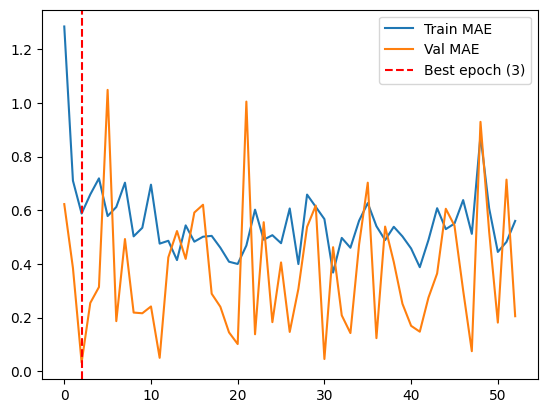

In [10]:
best_val_mae = min(history.history['val_mae'])
best_epoch = history.history['val_mae'].index(best_val_mae) + 1  # +1 since epochs start at 1
print(f"Best epoch: {best_epoch}, Val MAE: {best_val_mae:.4f}")

plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.axvline(x=best_epoch-1, color='red', linestyle='--', label=f'Best epoch ({best_epoch})')
plt.legend()
plt.show()

## Not enough data

Biggest tell: Our train MAE is higher than our Validation, its also very erratic... we'll have to use simpler models as RNN's will require a much higher volume of data